In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import matplotlib.cm as cm
import scipy 

from tqdm import tqdm

import emcee
import corner

# import marvin
import pyneb as pn
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit
from scipy.optimize import minimize
import scipy.stats as stats

sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/spirals')
from SHMR_functions import shmr_RP11

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [3]:
# PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
# DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
# VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [4]:
ellipticals = master_table[master_table['elliptical_mask']==1]
spirals = master_table[master_table['spiral_mask']==1]

In [8]:
spirals_cut = spirals[np.logical_and(spirals['CMD_class']==1, spirals['logHI_h'] >0)]

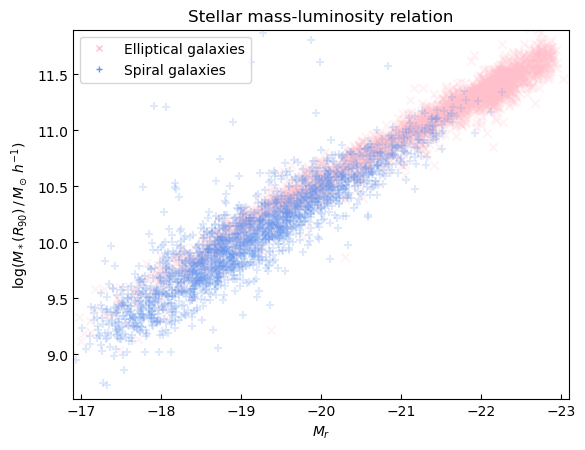

In [29]:
plt.scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
plt.scatter(spirals_cut['rabsmag'], spirals_cut['M_disk'], color='cornflowerblue', marker='+', alpha=0.2)
plt.xlim(-16.9,-23.1)
plt.ylim(8.6,11.9)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$\log(M_*(R_{90})\, /\, M_\odot\,h^{-1})$')
plt.tick_params(axis='both', direction='in')

legend_elements = [Line2D([0], [0], marker='x', color='w', label='Elliptical galaxies',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spiral galaxies',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  ]


plt.legend(handles=legend_elements,)


plt.title(r'Stellar mass-luminosity relation',)
plt.savefig('/Users/nityaravi/Documents/cuip2026/the art of presenting/plot1.png', bbox_inches='tight')

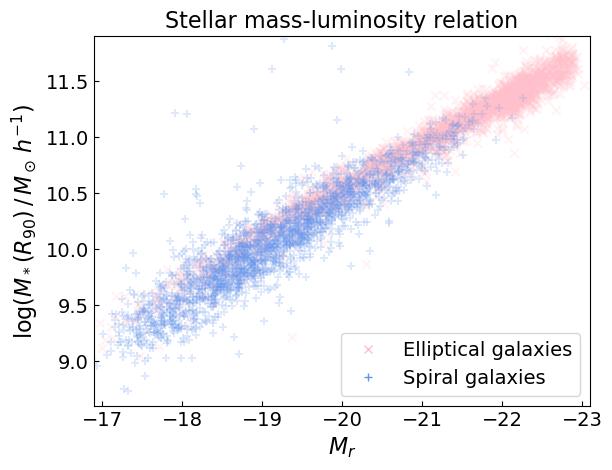

In [30]:
plt.scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
plt.scatter(spirals_cut['rabsmag'], spirals_cut['M_disk'], color='cornflowerblue', marker='+', alpha=0.2)
plt.xlim(-16.9,-23.1)
plt.ylim(8.6,11.9)

legend_elements = [Line2D([0], [0], marker='x', color='w', label='Elliptical galaxies',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                   Line2D([0], [0], marker='+', color='w', label='Spiral galaxies',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  ]


plt.legend(handles=legend_elements,fontsize=14)


plt.xlabel(r'$M_r$', fontsize=16)
plt.ylabel(r'$\log(M_*(R_{90})\, /\, M_\odot\,h^{-1})$', fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)

plt.title(r'Stellar mass-luminosity relation', fontsize=16)


plt.savefig('/Users/nityaravi/Documents/cuip2026/the art of presenting/plot2.png', bbox_inches='tight')

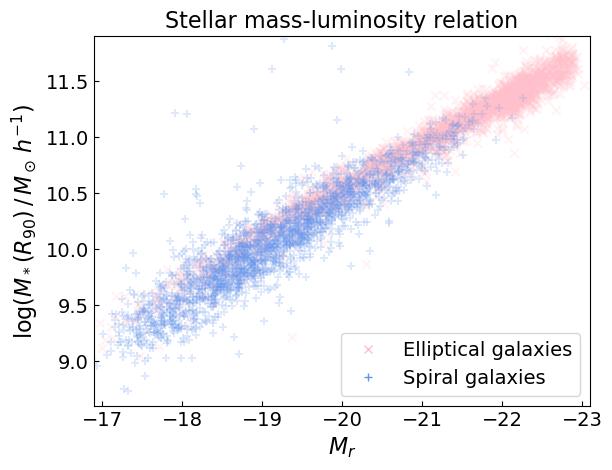

In [31]:
plt.scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
plt.scatter(spirals_cut['rabsmag'], spirals_cut['M_disk'], color='cornflowerblue', marker='+', alpha=0.2)
plt.xlim(-16.9,-23.1)
plt.ylim(8.6,11.9)

legend_elements = [Line2D([0], [0], marker='x', color='w', label='Elliptical galaxies',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                   Line2D([0], [0], marker='+', color='w', label='Spiral galaxies',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  ]


plt.legend(handles=legend_elements,fontsize=14)


plt.xlabel(r'$M_r$', fontsize=16)
plt.ylabel(r'$\log(M_*(R_{90})\, /\, M_\odot\,h^{-1})$', fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)

plt.title(r'Stellar mass-luminosity relation', fontsize=16)


plt.savefig('/Users/nityaravi/Documents/cuip2026/the art of presenting/plot3.png', bbox_inches='tight')

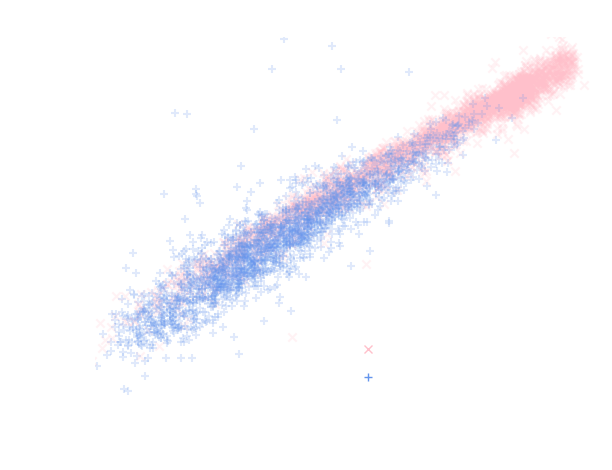

In [45]:
fig, ax = plt.subplots()

plt.scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
plt.scatter(spirals_cut['rabsmag'], spirals_cut['M_disk'], color='cornflowerblue', marker='+', alpha=0.2)
plt.xlim(-16.9,-23.1)
plt.ylim(8.6,11.9)

legend_elements = [Line2D([0], [0], marker='x', color='w', label='Elliptical galaxies',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6, linestyle='none'),
                   Line2D([0], [0], marker='+', color='w', label='Spiral galaxies',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6, linestyle='none'),
                  ]


plt.legend(handles=legend_elements,fontsize=14, labelcolor='w', facecolor='none', edgecolor='w')


plt.xlabel(r'$M_r$', fontsize=16, color='w')
plt.ylabel(r'$\log(M_*(R_{90})\, /\, M_\odot\,h^{-1})$', fontsize=16, color='w')
plt.tick_params(axis='both', direction='in', labelsize=14, colors='w')

plt.title(r'Stellar mass-luminosity relation', fontsize=16, color='w')
ax.spines['bottom'].set_color('w')
ax.spines['top'].set_color('w') 
ax.spines['right'].set_color('w')
ax.spines['left'].set_color('w')

plt.savefig('/Users/nityaravi/Documents/cuip2026/the art of presenting/plot4.png', bbox_inches='tight', transparent=True)